In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
# CSV Master (path to be adjusted accordingly)
file_path = "../raw_data/respiratory_features_master_forXGboost.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"done! {len(df)} lines")
    
    # check NaNs
    nans = df.isnull().sum().sum()
    print(f"missing values: {nans}")
    
    # columns
    print(f"cols: {df.columns.tolist()}")
    display(df.head())
else:
    print("check path")

done! 920 lines
missing values: 0
cols: ['rms_mean', 'zcr_mean', 'centroid_mean', 'rolloff_mean', 'flux_mean', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'filename', 'patient_id']


,rms_mean,zcr_mean,centroid_mean,rolloff_mean,flux_mean,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,filename,patient_id
0,0.353043,0.000716,43.795286,41.528320,0.433962,-416.897430,62.325581,46.420395,35.231888,30.405567,29.885906,28.196938,24.402584,21.075634,19.104095,17.423349,14.515306,10.367791,223_1b1_Pr_sc_Meditron.wav,223
1,0.131263,0.001339,133.438929,65.929846,0.431228,-488.044525,75.769440,61.811069,49.042362,39.135307,31.911039,25.999527,21.384661,17.560677,14.248250,11.581615,10.005250,9.039628,134_2b2_Al_mc_LittC2SE.wav,134
2,0.147832,0.023517,1299.190164,2820.226061,1.032007,-217.973022,100.233185,4.600662,29.796114,15.727752,17.164007,14.577301,18.850311,10.304487,13.588282,5.419698,6.978378,4.364567,170_1b4_Al_mc_AKGC417L.wav,170
3,0.236638,0.007697,337.687454,289.700565,0.922199,-330.460999,147.148163,79.223549,52.871487,31.837748,21.586948,15.103443,11.056579,8.015654,6.217966,4.712320,3.982452,3.184886,203_1p3_Pl_mc_AKGC417L.wav,203
4,0.080208,0.026243,1100.981859,2400.411740,1.046043,-312.236053,141.208221,8.134517,29.663057,17.224943,30.943031,15.562644,-0.528191,-3.173283,9.954062,7.148951,6.205405,1.809195,207_2b3_Tc_mc_AKGC417L.wav,207


In [33]:
# load diagnosis 
diag_path = "../raw_data/patient_diagnosis.csv" 

df_diag = pd.read_csv(diag_path)

df_diag.head()

,101,URTI
0,102,Healthy
1,103,Asthma
2,104,COPD
3,105,URTI
4,106,COPD


In [34]:
df_diag = pd.read_csv(diag_path, names=['patient_id', 'diagnosis'])

df_diag

,patient_id,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI
...,...,...
121,222,COPD
122,223,COPD
123,224,Healthy
124,225,Healthy


In [35]:
# int
df['patient_id'] = df['patient_id'].astype(int)
df_diag['patient_id'] = df_diag['patient_id'].astype(int)

# merge
df_final = pd.merge(df, df_diag, on='patient_id', how='left')

print(f"merge done")
print(f"shape: {df_final.shape}")
print(f"disease dist:\n{df_final['diagnosis'].value_counts()}")

display(df_final.head())

merge done
shape: (920, 21)
disease dist:
diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


,rms_mean,zcr_mean,centroid_mean,rolloff_mean,flux_mean,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,filename,patient_id,diagnosis
0,0.353043,0.000716,43.795286,41.528320,0.433962,-416.897430,62.325581,46.420395,35.231888,30.405567,...,28.196938,24.402584,21.075634,19.104095,17.423349,14.515306,10.367791,223_1b1_Pr_sc_Meditron.wav,223,COPD
1,0.131263,0.001339,133.438929,65.929846,0.431228,-488.044525,75.769440,61.811069,49.042362,39.135307,...,25.999527,21.384661,17.560677,14.248250,11.581615,10.005250,9.039628,134_2b2_Al_mc_LittC2SE.wav,134,COPD
2,0.147832,0.023517,1299.190164,2820.226061,1.032007,-217.973022,100.233185,4.600662,29.796114,15.727752,...,14.577301,18.850311,10.304487,13.588282,5.419698,6.978378,4.364567,170_1b4_Al_mc_AKGC417L.wav,170,COPD
3,0.236638,0.007697,337.687454,289.700565,0.922199,-330.460999,147.148163,79.223549,52.871487,31.837748,...,15.103443,11.056579,8.015654,6.217966,4.712320,3.982452,3.184886,203_1p3_Pl_mc_AKGC417L.wav,203,COPD
4,0.080208,0.026243,1100.981859,2400.411740,1.046043,-312.236053,141.208221,8.134517,29.663057,17.224943,...,15.562644,-0.528191,-3.173283,9.954062,7.148951,6.205405,1.809195,207_2b3_Tc_mc_AKGC417L.wav,207,COPD


In [36]:
#crazy class imbalance. make XGboost ready:

In [37]:
# transform words (COPD, Healthy...) in num (0, 1, 2...)
le = LabelEncoder()
df_final['target'] = le.fit_transform(df_final['diagnosis'])

# so we know who is who
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"class mapping: {mapping}")

# define X and y (target)
# remove columns that are not numbers for now?
X = df_final.drop(columns=['filename', 'patient_id', 'diagnosis', 'target'])
y = df_final['target']
groups = df_final['patient_id'] # split per id

print(f"features: {X.shape[1]} cols")

class mapping: {'Asthma': np.int64(0), 'Bronchiectasis': np.int64(1), 'Bronchiolitis': np.int64(2), 'COPD': np.int64(3), 'Healthy': np.int64(4), 'LRTI': np.int64(5), 'Pneumonia': np.int64(6), 'URTI': np.int64(7)}
features: 18 cols


## IT'S TIME FOR XGBOOST - just keeping this for later, because its not working :(

# but 1st: cross validation setup
# Using 5-fold or 3-fold? cv - maybe 3 is better for ashtma and the ones that don't have a lot of referebce?
gkf = GroupKFold(n_splits=3)

#error because we don't have sequential classes on the split. adding
num_classes = len(np.unique(y))

# modeml training loop

fold = 1
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # initialize XGBoost classifier
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob', # used for multiclass classification
        num_class=num_classes, # gemini suggested this due to the error of class numbers
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    
    # train the model
    model.fit(X_train, y_train)
    
    # evaluet current fold
    score = model.score(X_test, y_test)
    print(f"fold {fold} accuracy: {score:.4f}")
    
    # stop at first fold - initial validation
    if fold == 1:
        y_pred = model.predict(X_test)
        print("\n classification report - fold 1:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        
        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Fold 1')
        plt.show()
        
    fold += 1



In [40]:
# IT'S TIME FOR XGBOOST 2nd TRYYYY

#data cleaning - rare classes

# identify classes with too few samples to be split
class_counts = df_final['diagnosis'].value_counts()
to_keep = class_counts[class_counts >= 3].index
df_filtered = df_final[df_final['diagnosis'].isin(to_keep)].copy()

print(f"dropped classes: {set(df_final['diagnosis'].unique()) - set(to_keep)}")

# reencode sequentially 

# that's a must 0, 1, 2, 3... according to gemini: leave no no gaps
le_final = LabelEncoder()
df_filtered['target'] = le_final.fit_transform(df_filtered['diagnosis'])

X = df_filtered.drop(columns=['filename', 'patient_id', 'diagnosis', 'target'])
y = df_filtered['target']
groups = df_filtered['patient_id']

# training loop - from previous code

gkf = GroupKFold(n_splits=3)
fold = 1

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # XGBoost should be happy because y starts at 0 and is sequential :)
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob',# used for multiclass classification
        #num_class=num_classes, # gemini suggested this due to the error of class numbers - not needed now
        random_state=42,
        eval_metric='mlogloss'
    )
    
    model.fit(X_train, y_train)
    
    score = model.score(X_test, y_test)
    print(f"Fold {fold} Accuracy: {score:.4f}")
    
    if fold == 1:
        y_pred = model.predict(X_test)
        print("\nClassification Report - Fold 1:")
        print(classification_report(y_test, y_pred, target_names=le_final.classes_))
    
    fold += 1



dropped classes: {'LRTI', 'Asthma'}
Fold 1 Accuracy: 0.8529

Classification Report - Fold 1:
                precision    recall  f1-score   support

Bronchiectasis       0.00      0.00      0.00         5
 Bronchiolitis       0.33      0.20      0.25         5
          COPD       0.92      0.95      0.94       269
       Healthy       0.60      0.30      0.40        10
     Pneumonia       0.06      0.12      0.08         8
          URTI       0.17      0.11      0.13         9

      accuracy                           0.85       306
     macro avg       0.35      0.28      0.30       306
  weighted avg       0.84      0.85      0.85       306



/home/totid/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/totid/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/totid/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

Fold 2 Accuracy: 0.8987
Fold 3 Accuracy: 0.8295


<Figure size 1000x800 with 0 Axes>

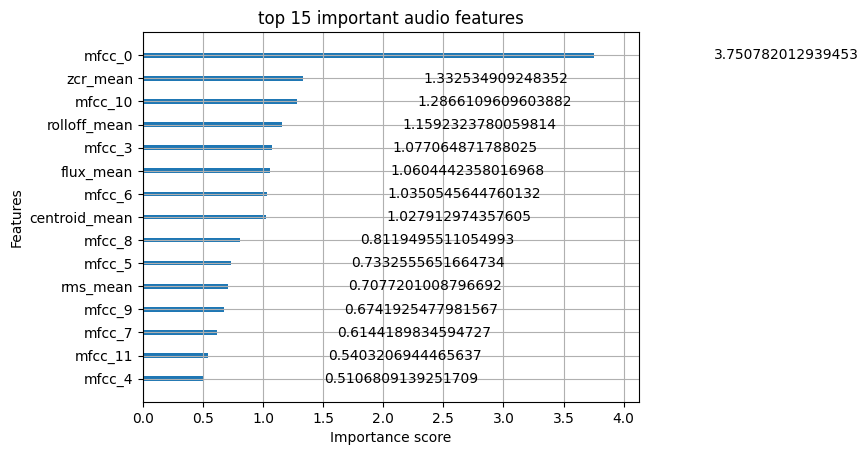

In [39]:
# feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('top 15 important audio features')
plt.show()
